In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, log_loss, roc_auc_score)
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, 
ConfusionMatrixDisplay, classification_report, RocCurveDisplay, roc_curve)

from xgboost import XGBClassifier

In [3]:
RANDOM_STATE=42
data = load_breast_cancer(as_frame=True)
X = data.data
y = data.target
print("X shape", X.shape)
print("y shape", y.shape)
print("\nClass disturbution")
print(y.value_counts())
print("\nFeature names")
print(X.columns.tolist())

X shape (569, 30)
y shape (569,)

Class disturbution
target
1    357
0    212
Name: count, dtype: int64

Feature names
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']


In [4]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=RANDOM_STATE
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

print("Test:", X_train.shape)
print("Train:", X_val.shape)
print("Test:", X_test.shape)

Test: (398, 30)
Train: (85, 30)
Test: (86, 30)


In [5]:
model = XGBClassifier(
    n_estimators = 100,
    random_state=RANDOM_STATE,
    eval_metric="logloss"
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [6]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 Score:", round(f1, 4))

Accuracy: 0.9186
Precision: 0.9273
Recall: 0.9444
F1 Score: 0.9358


In [7]:
print(classification_report(y_test, y_pred, target_names=data.target_names))

              precision    recall  f1-score   support

   malignant       0.90      0.88      0.89        32
      benign       0.93      0.94      0.94        54

    accuracy                           0.92        86
   macro avg       0.92      0.91      0.91        86
weighted avg       0.92      0.92      0.92        86



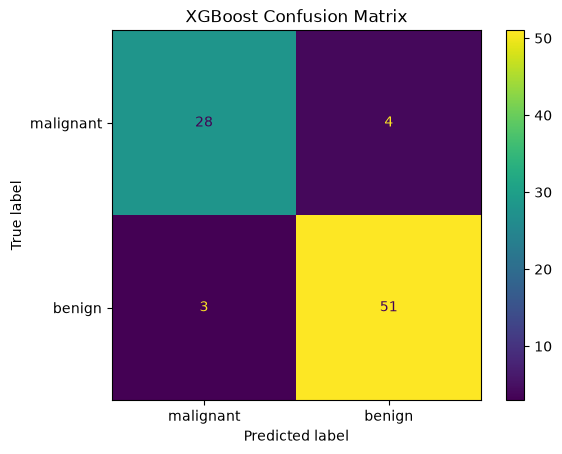

In [8]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)

disp.plot()
plt.title("XGBoost Confusion Matrix")
plt.show()

In [9]:
y_prob = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob)

print("ROC_AUC:", round(auc, 4))

ROC_AUC: 0.9907


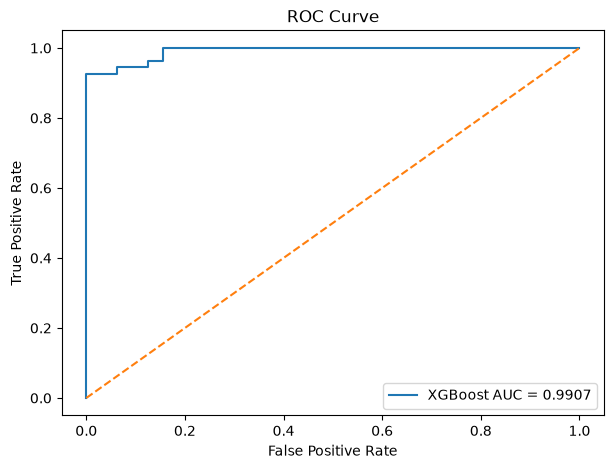

In [10]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"XGBoost AUC = {auc:.4f}")
plt.plot(
    [0, 1],
    [0, 1],
    linestyle = "--"
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [11]:
model = XGBClassifier(
    n_estimators = 500,
    learning_rate=0.05,
    random_state=RANDOM_STATE,
    eval_metric="logloss"
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

Accuracy: 0.9302325581395349
F1: 0.9454545454545454


# Early stopping

In [12]:
model = XGBClassifier(
    n_estimators = 500,
    learning_rate=0.03,
    max_depth=6,
    random_state=RANDOM_STATE,
    eval_metric="logloss",
    early_stopping_rounds = 50
)

model.fit(
    X_train, 
    y_train, 
    eval_set=[(X_val, y_val)], 
    verbose=False
)

print("Best iteration:", model.best_iteration)

Best iteration: 497


# Early stopping natijasi

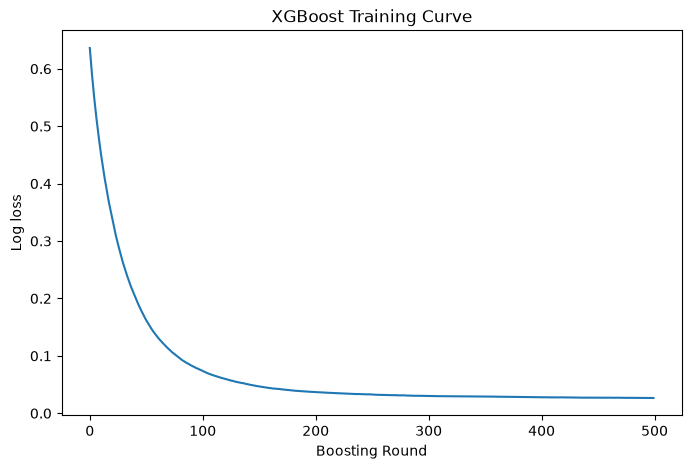

In [13]:
results = model.evals_result()
train_loss = results["validation_0"]["logloss"]
plt.figure(figsize=(8, 5))
plt.plot(train_loss)
plt.xlabel("Boosting Round")
plt.ylabel("Log loss")
plt.title("XGBoost Training Curve")
plt.show()

# Validation + test natijasi

In [14]:
y_val_pred = model.predict(X_val)
y_test_pred = model.predict(X_test)

print("\nVALIDATION")
print("Accuracy:", round(accuracy_score(y_val, y_val_pred), 4))
print("F1      :", round(f1_score(y_val, y_val_pred), 4))

print("\nTEST")
print("Accuracy:", round(accuracy_score(y_test, y_test_pred), 4))
print("F1      :", round(f1_score(y_test, y_test_pred), 4))


VALIDATION
Accuracy: 1.0
F1      : 1.0

TEST
Accuracy: 0.9302
F1      : 0.9455
